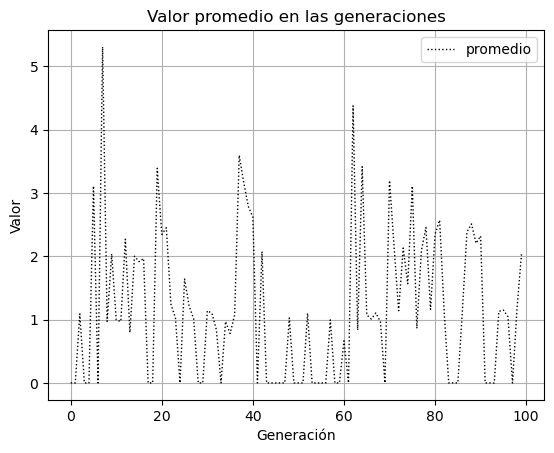

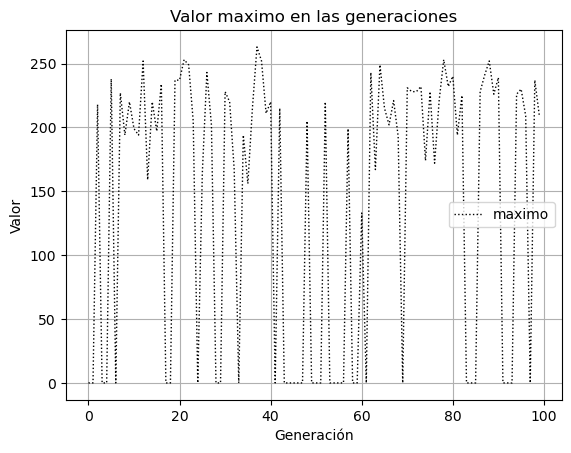

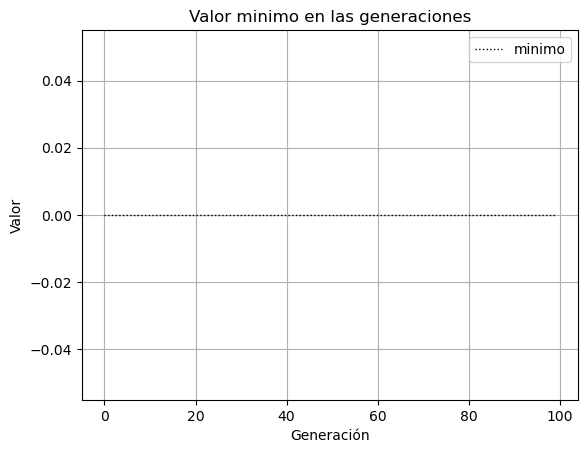

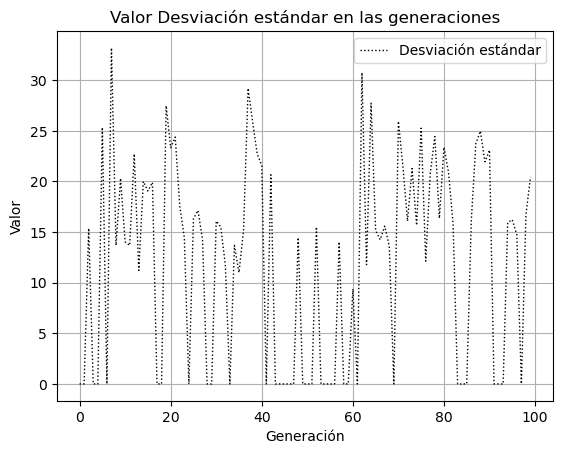

In [ ]:
from supervivencia import Con_elitismo, Sin_elitismo, Supervivencia
from carga import Carga
from grafica import Grafica, Grafica_lineas
from fitness import Fitness
import numpy as np
import numpy.typing as npt
from contenedor import Contenedor

# Configuración
tamano_poblacion: int = 100
max_generaciones: int = 100

# Métricas por generación
valor_minimo_generacion: list[int] = []
valor_maximo_generacion: list[int] = []
valor_promedio_generacion: list[float] = []
valor_desviacion_std_generacion: list[float] = []

# Inicialización
carga = Carga()
cargas: list[npt.NDArray[np.int32]] = carga.generar_carga()


poblacion: list[Contenedor] = []

# Llevamos la carga de los contenedores
for carga in cargas:
    contenedor = Contenedor(carga=carga)
    poblacion.append(contenedor)


supervivencia: Supervivencia = Con_elitismo()
fitness: Fitness 
poblacion: list[Contenedor] = []

# Evolución
for generacion in range(max_generaciones):
    
    aptitudes:list[int] = []

    # Llevamos la carga a los contenedores
    for carga in cargas:
        contenedor = Contenedor(carga=carga)
        poblacion.append(contenedor)

    # Calculamos su fitnes
    for contenedor in poblacion:
        fitness = Fitness(carga=contenedor.carga)
        aptitudes.append(fitness.calcular_fitness())
    
    # Llevamos su fitnes al contenedor    
    for posicion, fitness in enumerate(aptitudes):
        poblacion[posicion].fitness = fitness


    valor_maximo:int = (np.max(aptitudes))
    valor_minimo:int = (np.min(aptitudes))
    valor_promedio: float = (np.mean(aptitudes))
    valor_desviacion_std: float = (np.std(aptitudes))


    (nueva_generacion) = supervivencia.seleccion_supervivencia( poblacion=poblacion,
                                                                tamano_poblacion=tamano_poblacion,
                                                                generacion=generacion,
                                                                max_generaciones=max_generaciones
                                                            )

    valor_maximo_generacion.append(valor_maximo)
    valor_minimo_generacion.append(valor_minimo)
    valor_promedio_generacion.append(valor_promedio)
    valor_desviacion_std_generacion.append(valor_desviacion_std)

    poblacion = nueva_generacion


grafica_promedio: Grafica = Grafica_lineas()
grafica_maximo: Grafica = Grafica_lineas()
grafica_minimo: Grafica = Grafica_lineas()
grafica_desviacion_std: Grafica = Grafica_lineas()

grafica_promedio.generar_grafica(datos=valor_promedio_generacion,etiqueta="promedio")
grafica_maximo.generar_grafica(datos=valor_maximo_generacion,etiqueta="maximo")
grafica_minimo.generar_grafica(datos=valor_minimo_generacion,etiqueta="minimo")
grafica_desviacion_std.generar_grafica(datos=valor_desviacion_std_generacion,etiqueta="Desviación estándar")
